# 2D Stabelement (Truss) – Beschreibung und Implementierung

Dieser Abschnitt beschreibt den 2D‑Stab (Truss) ausschließlich mit mathematischen Formeln (LaTeX) und erläutert die einzelnen Rechenschritte. Zur Implementierungsreferenz sind jeweils die zugehörigen Zeilen in `Programmieraufgabe/solver.py` angegeben.


## Elementbeschreibung

- **Knoten pro Element**: 2
- **Freiheitsgrade je Knoten**: $u_x, u_y$ ⇒ insgesamt 4 DOFs je Element.
- **Globale Unbekannten**: $\mathbf{U} = [u_{1x}, u_{1y}, u_{2x}, u_{2y},\ldots,u_{nx},u_{ny}]^{\top}$.
- **Gleichgewicht (global)**: $\mathbf{K}\,\mathbf{U} = \mathbf{R}$.
- **DOF-Abbildung**: Sei $\varphi:\, \text{NodeID} \mapsto \{0,\ldots,N-1\}$ die Knotenindizierung. Dann
  $ d_x(n) = 2\,\varphi(n),\quad d_y(n) = 2\,\varphi(n)+1. $
  (vgl. `solver.py` Z. 29–31, 36–39)

- **Physikalisches Verhalten**: Das 2D‑Stabelement überträgt ausschließlich axiale Kräfte (Zug/Druck), keine Biegung/Schub.

## Geometrie und Richtungskosinus

Für ein Element mit Endknoten $1:(x_1,y_1)$ und $2:(x_2,y_2)$ gilt
$ L = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}, \qquad c = \frac{x_2-x_1}{L}, \quad s = \frac{y_2-y_1}{L}. $
Der Richtungsvektor in globalen Koordinaten ist $\boldsymbol{\ell} = [\,c,\ s\,]^{\top}$.

Numerische Robustheit: Elemente mit $L \approx 0$ werden verworfen (vgl. `solver.py` Z. 47–49). Koordinaten- und Längenberechnung: (vgl. `solver.py` Z. 43–49).

## Lokale Steifigkeit und Transformation

In lokalen Koordinaten (Stabachse) gilt:
$$
\mathbf{k}_\ell^{(e)} = \frac{EA}{L}
\begin{bmatrix}
1 & -1\\
-1 & 1
\end{bmatrix}.
$$

Mit Richtungskosinus $c=\tfrac{x_2-x_1}{L}$, $s=\tfrac{y_2-y_1}{L}$ und $L=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$ (vgl. `solver.py` Z. 43–49).
Die Abbildung von globalen Verschiebungen $\mathbf{u}_g^{(e)}=[u_{1x},u_{1y},u_{2x},u_{2y}]^\top$ auf lokale axiale Verschiebungen $\mathbf{u}_\ell^{(e)}=[u_{1\ell},u_{2\ell}]^\top$ erfolgt mit
$$
\mathbf{u}_\ell^{(e)} = \mathbf{T}\,\mathbf{u}_g^{(e)}, \qquad
\mathbf{T} =
\begin{bmatrix}
 c & s & 0 & 0\\
 0 & 0 & c & s
\end{bmatrix}.
$$
Daraus folgt die globale Elementsteifigkeit
$$
\mathbf{k}_g^{(e)} = \mathbf{T}^\top\,\mathbf{k}_\ell^{(e)}\,\mathbf{T}
= \frac{EA}{L}
\begin{bmatrix}
 c^2 & cs & -c^2 & -cs\\
 cs & s^2 & -cs & -s^2\\
 -c^2 & -cs & c^2 & cs\\
 -cs & -s^2 & cs & s^2
\end{bmatrix}.
$$
Implementierungsreferenz: Bildung von $c,s,L$ und direkte Konstruktion von $\mathbf{k}_g^{(e)}$ (solver.py Z. 43–59).

## Globale Elementsteifigkeit (kompakt)

Mit
$$ \alpha^{(e)} = \frac{E^{(e)} A^{(e)}}{L^{(e)}} $$
lautet die globale 4×4‑Elementsteifigkeit
$$
\mathbf{k}_g^{(e)} = \alpha^{(e)}
\begin{bmatrix}
 c^2 & cs & -c^2 & -cs\\
 cs & s^2 & -cs & -s^2\\
 -c^2 & -cs & c^2 & cs\\
 -cs & -s^2 & cs & s^2
\end{bmatrix},
$$
wobei $c=\tfrac{x_2-x_1}{L},\ s=\tfrac{y_2-y_1}{L},\ L=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}.$

Parameterherkunft: $E^{(e)},A^{(e)}$ stammen aus den Elementdaten; sind sie nicht gesetzt, werden Standardwerte aus dem Modell verwendet (vgl. `solver.py` Z. 50–59).

## Elementdaten (Modell)

Jedes Element $e$ ist durch seine Endknoten $n_1, n_2$, Material $E^{(e)}$ und Querschnittsfläche $A^{(e)}$ charakterisiert:
$$
 e \equiv (n_1, n_2, E^{(e)}, A^{(e)}), \qquad n_i \in \mathcal{N}.
$$
Die Endknoten besitzen globale Koordinaten $(x_1,y_1)$, $(x_2,y_2)$.
Nicht explizit gesetzte Parameter $E^{(e)},A^{(e)}$ werden aus Modell‑Standardwerten übernommen.

Implementierungsreferenz: Zugriff auf Element‑ und Default‑Parameter sowie Knotenkoordinaten (solver.py Z. 41–56, 50, 148–150).

## Assemblierung des Gesamtsystems

Sei $\mathcal{E}$ die Menge aller Elemente und $n_\text{dof}=2\,|\mathcal{N}|$ die Anzahl globaler Freiheitsgrade. Für jedes Element $e$ mit globalen DOF-Indizes
$$
\mathbf{d}^{(e)} = [\,d_1, d_2, d_3, d_4\,]^{\top} = [\,d_x(n_1), d_y(n_1), d_x(n_2), d_y(n_2)\,]^{\top}.
$$
Hierbei bezeichnet $d_a^{(e)}$ den globalen Freiheitsgrad‑Index, der zur lokalen Position $a\in\{1,2,3,4\}$ des Elements $e$ gehört, also
$ d_1^{(e)}=d_x(n_1),\ d_2^{(e)}=d_y(n_1),\ d_3^{(e)}=d_x(n_2),\ d_4^{(e)}=d_y(n_2). $

Sei $\mathbf{A}^{(e)} \in \{0,1\}^{n_\text{dof}\times 4}$ die (boolesche) Assemblierungsmatrix, so dass
$$ \mathbf{u}^{(e)} = (\mathbf{A}^{(e)})^{\top} \mathbf{U}. $$
Die globale Steifigkeitsmatrix ergibt sich durch Summation aller Elementbeiträge
$$
\mathbf{K} = \sum_{e\in\mathcal{E}} \mathbf{A}^{(e)}\, \mathbf{k}_g^{(e)}\, (\mathbf{A}^{(e)})^{\top}.
$$
Äquivalent komponentenweise mit Kronecker‑Delta $\delta_{ij}$:
$$
K_{ij} \,=\, \sum_{e\in\mathcal{E}} \sum_{a=1}^{4} \sum_{b=1}^{4} k_{ab}^{(e)}\, \delta_{i,\,d_a^{(e)}}\, \delta_{j,\,d_b^{(e)}}.
$$
Dabei bezeichnen $d_a^{(e)}$ und $d_b^{(e)}$ die oben definierten globalen DOF‑Indizes der lokalen Positionen $a$ bzw. $b$; $k_{ab}^{(e)}$ ist der Eintrag der 4\times4‑Elementsteifigkeitsmatrix.

Implementierungsreferenz: doppelte Schleife über $i,j$ und Addition in $\mathbf{K}$ (solver.py Z. 60–64).

## Knotenlasten und Lagerbedingungen

- **Knotenlasten**: Der globale Lastvektor $\mathbf{R}\in\mathbb{R}^{n_\text{dof}}$ entsteht durch Summation der an Knoten angesetzten Komponentenlasten
  $$
  R_i \,=\, \sum_{\ell\in\mathcal{L}} \big(\, \delta_{i,\,d_x(n_\ell)}\, f^{(\ell)}_x \;+
  \delta_{i,\,d_y(n_\ell)}\, f^{(\ell)}_y \,\big),
  $$
  wobei $\mathcal{L}$ die Menge der Lasten ist und $d_x(n), d_y(n)$ die DOF‑Indizes des Knotens $n$ bezeichnen. (vgl. `solver.py` Z. 65–68)

- **Lagerbedingungen**: Die Menge der fixierten Freiheitsgrade ist
  $$
  \mathcal{F} = \{\, d_x(n)\mid u_x\text{ am Knoten }n \text{ fix}\,\} \;\cup\; \{\, d_y(n)\mid u_y\text{ am Knoten }n \text{ fix}\,\}.
  $$
  Die freien DOFs sind das Komplement $\mathcal{F}^c$ in $\{0,\ldots,n_\text{dof}-1\}$. (vgl. `solver.py` Z. 70–80, 81–85)

Hinweis: Die DOF‑Abbildung $d_x(n), d_y(n)$ folgt der in der Elementbeschreibung angegebenen Zuordnung (vgl. `solver.py` Z. 36–39).

## Lösen des Gleichungssystems

Sei $\mathcal{F}$ die Menge fixierter DOFs und $\mathcal{F}^c$ die Menge freier DOFs. Durch Auswahl der entsprechenden Zeilen/Spalten von $\mathbf{K}$ und Einträge von $\mathbf{R}$ ergibt sich
$$
\mathbf{K}_{ff} = \mathbf{K}_{\mathcal{F}^c,\,\mathcal{F}^c},\quad
\mathbf{R}_f = \mathbf{R}_{\mathcal{F}^c},\quad
\mathbf{U}_F = \mathbf{0}.
$$
Die Gleichung reduziert sich auf
$$
\mathbf{K}_{ff}\,\mathbf{U}_f = \mathbf{R}_f, \qquad \mathbf{U} = \begin{bmatrix} \mathbf{U}_f \\ \mathbf{0} \end{bmatrix}
\ \text{(in der DOF‑Reihenfolge frei/fest)}.
$$
Rekonstruktion komponentenweise: Für jeden globalen DOF $i$
$$
U_i = \begin{cases}
(U_f)_k, & \text{falls } i=\mathcal{F}^c[k],\\[2pt]
0, & \text{falls } i\in\mathcal{F}.
\end{cases}
$$
Implementierungsreferenz: Bestimmung von $\mathcal{F},\,\mathcal{F}^c$ (solver.py Z. 81–85) und Lösung $\mathbf{U}_f$ sowie Einbau in $\mathbf{U}$ (solver.py Z. 93–96).

## Auflagerkräfte (Reaktionen)

Die Auflagerreaktionen ergeben sich aus dem globalen Gleichgewicht
$$
\mathbf{R}_{\text{reac}} = \mathbf{K}\,\mathbf{U} - \mathbf{R}.
$$
Nur an fixierten Freiheitsgraden $\mathcal{F}$ treten Reaktionen auf; an freien DOFs $\mathcal{F}^c$ gilt idealerweise $R_{\text{reac},i}=0$ (numerische Rundung ausgenommen).

- **Berechnung auf DOF‑Ebene**: $\mathbf{r} = \mathbf{K}\,\mathbf{U} - \mathbf{R}$. Die Reaktionsliste entsteht durch Auswahl der Einträge $r_d$ mit $d\in\mathcal{F}$. (vgl. `solver.py` Z. 98–106)
- **Zuordnung zu Knoten**: Sei $d$ ein globaler DOF‑Index. Der zugehörige Knoten ist $n = \lfloor d/2 \rfloor$, die Richtung ist $x$ für gerade $d$ und $y$ für ungerade $d$. (vgl. `solver.py` Z. 100–106)
- **Summation pro Knoten**: Für jeden Knoten $n$ werden die Beiträge $r_x, r_y$ summiert, um die Knotenreaktionen zu erhalten. (vgl. `solver.py` Z. 108–116)
- **Gleichgewichtskontrolle**: $\sum r_x,\ \sum r_y$ und Resultierende $\sum R = \sqrt{(\sum r_x)^2 + (\sum r_y)^2}$. (vgl. `solver.py` Z. 117–119)

## Nachverarbeitung: Stabkraft, Dehnung, Spannung

Der elementare Verschiebungsvektor in globaler Reihenfolge lautet
$$
\mathbf{u}^{(e)} = [\,u_{1x},\ u_{1y},\ u_{2x},\ u_{2y}\,]^{\top}
= [\,U_{d_x(n_1)},\ U_{d_y(n_1)},\ U_{d_x(n_2)},\ U_{d_y(n_2)}\,]^{\top}.
$$
Die axiale Verlängerung $\delta^{(e)}$ (positiv: Zug) ist
$$
\delta^{(e)} = [-c,\ -s,\ c,\ s] \, \mathbf{u}^{(e)},\quad
c=\frac{x_2-x_1}{L},\ s=\frac{y_2-y_1}{L},\ L=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}.
$$
Daraus folgen für jedes Element $e$:
$$
N^{(e)} = \frac{E^{(e)}A^{(e)}}{L^{(e)}}\,\delta^{(e)},\qquad
\varepsilon^{(e)} = \frac{\delta^{(e)}}{L^{(e)}},\qquad
\sigma^{(e)} = E^{(e)}\,\varepsilon^{(e)}.
$$
Implementierungsreferenz: Bildung von $\mathbf{u}^{(e)}$, $\delta^{(e)}$, $N^{(e)}$, $\varepsilon^{(e)}$, $\sigma^{(e)}$ (solver.py Z. 145–152).

## Ergebnissammlung und Ausgabe

Nach der Lösung werden die Ergebnisse strukturiert abgelegt:

- **Knotenverschiebungen**: Für alle Knoten $n$ mit Indexabbildung $\varphi(n)$ gilt
  $$
  (u_x(n), u_y(n)) = \big( U_{2\varphi(n)},\ U_{2\varphi(n)+1} \big),
  $$
  woraus die Knotenliste $\{(n, u_x, u_y)\}$ gebildet wird. (vgl. `solver.py` Z. 122–127)

- **Elementgrößen**: Für jedes Element $e$ werden aus $\delta^{(e)}$ die Größen $N^{(e)},\ \varepsilon^{(e)},\ \sigma^{(e)}$ bestimmt (siehe Abschnitt Nachverarbeitung) und als Liste $\{(e, N, \varepsilon, \sigma)\}$ gesammelt. (vgl. `solver.py` Z. 128–159)

- **Auflagerreaktionen**: Nach Aggregation pro Knoten ergeben sich $(R_x(n), R_y(n))$ sowie Summen
  $$
  \sum R_x = \sum_n R_x(n),\quad \sum R_y = \sum_n R_y(n),\quad \sum R = \sqrt{(\sum R_x)^2 + (\sum R_y)^2}.
  $$
  (vgl. `solver.py` Z. 108–119)

- **Metadaten**: Anzahl DOF, Anzahl freie/fixierte DOF. (vgl. `solver.py` Z. 165–169)

- **Struktur des Resultats**: Ergebnisse werden in einer Sammlung $\{\text{nodes},\ \text{elements},\ \text{reactions},\ \text{reactions\_sum},\ \text{metadata}\}$ zusammengeführt. (vgl. `solver.py` Z. 160–169)

- **Ausgabe**: Serielle Ablage als JSON‑Datei zur Weiterverarbeitung/Visualisierung. (vgl. `solver.py` Z. 174–179)

# Die drei Beispiele:

## Ein simples Brückenfachwerk

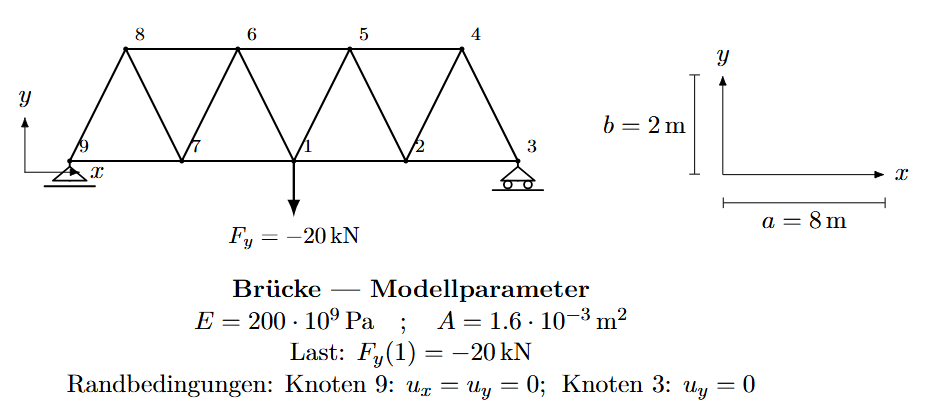

### Umsetzung im eigenem Preprozessor

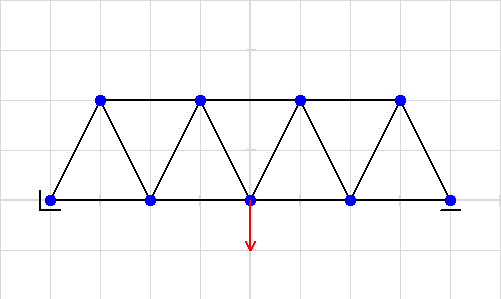

### Ergebins im eigenem Postprozessor

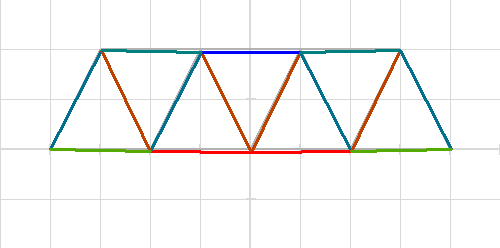
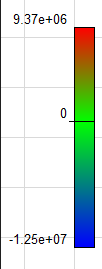

## Vergleich der Ergebnisse

### Knotenverschiebungen:

$\operatorname{rel} \Delta=\frac{\left|x_{\text {prog }}-x_{\text {abaqus }}\right|}{\max \left(\left|x_{\text {abaqus }}\right|, \text { tol }\right)} \cdot 100 \%$

| Node (Abaqus) | Node (Prog) | U1_prog [m] | U1_abaqus [m] | relΔU1 |  U2_prog [m] | U2_abaqus [m] | relΔU2   |
| ------------: | ----------: | ----------: | ------------: | :----- | -----------: | ------------: | :------- |
|             1 |           4 |    6.25e-05 |      6.25e-05 | 0%     | -0.000574539 |  -0.000574539 | 0%       |
|             2 |           6 |           0 |             0 | 0%     | -0.000212346 |  -0.000212346 | 0%       |
|             3 |           5 |  0.00021875 |    0.00021875 | 0%     | -0.000409068 |  -0.000409068 | 0%       |
|             4 |           7 |     0.00025 |       0.00025 | 0%     |            0 |             0 | 0%       |
|             5 |           3 |   0.0001875 |     0.0001875 | 0%     | -0.000574539 |  -0.000574539 | 0%       |
|             6 |           8 |     0.00025 |       0.00025 | 0%     | -0.000212346 |  -0.000212346 | 0%       |
|             7 |           9 |           0 |             0 | 0%     |            0 |             0 | 0%       |
|             8 |           2 |   3.125e-05 |     3.125e-05 | 0%     | -0.000409064 |  -0.000409068 | 0.00103% |
|             9 |           1 |    0.000125 |      0.000125 | 0%     | -0.000693136 |  -0.000693136 | 0%       |


### Elementdehnung 𝜀 und Spannung 𝜎

| Elem (Abaqus) | Elem (Prog) |   ε_prog [-] | ε_abaqus [-] | relΔε |  σ_prog [Pa] | σ_abaqus [Pa] | relΔσ |
| ------------: | ----------: | -----------: | -----------: | :---- | -----------: | ------------: | :---- |
|             1 |           9 |   -3.125e-05 |   -3.125e-05 | 0%    |    -6.25e+06 |     -6.25e+06 | 0%    |
|             2 |           2 |  3.49386e-05 |  3.49386e-05 | 0%    |  6.98771e+06 |   6.98771e+06 | 0%    |
|             3 |          11 |   1.5625e-05 |   1.5625e-05 | 0%    |    3.125e+06 |     3.125e+06 | 0%    |
|             4 |           3 | -3.49386e-05 | -3.49386e-05 | 0%    | -6.98771e+06 |  -6.98771e+06 | 0%    |
|             5 |           5 |    -6.25e-05 |    -6.25e-05 | 0%    |    -1.25e+07 |     -1.25e+07 | 0%    |
|             6 |          15 |   -3.125e-05 |   -3.125e-05 | 0%    |    -6.25e+06 |     -6.25e+06 | 0%    |
|             7 |           6 | -3.49386e-05 | -3.49386e-05 | 0%    | -6.98771e+06 |  -6.98771e+06 | 0%    |
|             8 |          14 |   1.5625e-05 |   1.5625e-05 | 0%    |    3.125e+06 |     3.125e+06 | 0%    |
|             9 |          10 | -3.49386e-05 | -3.49386e-05 | 0%    | -6.98771e+06 |  -6.98771e+06 | 0%    |
|            10 |           4 |  3.49386e-05 |  3.49386e-05 | 0%    |  6.98771e+06 |   6.98771e+06 | 0%    |
|            11 |           1 |   4.6875e-05 |   4.6875e-05 | 0%    |    9.375e+06 |     9.375e+06 | 0%    |
|            12 |           8 |  3.49386e-05 |  3.49386e-05 | 0%    |  6.98771e+06 |   6.98771e+06 | 0%    |
|            13 |          12 | -3.49386e-05 | -3.49386e-05 | 0%    | -6.98771e+06 |  -6.98771e+06 | 0%    |
|            14 |          13 |  3.49386e-05 |  3.49386e-05 | 0%    |  6.98771e+06 |   6.98771e+06 | 0%    |
|            15 |           7 |   4.6875e-05 |   4.6875e-05 | 0%    |    9.375e+06 |     9.375e+06 | 0%    |


### Reaktionskräfte an Lagern $R_x, R_y$

| Node (Abaqus) | Node (Prog) | Rx_prog [N] | Rx_abaqus [N] | relΔRx | Ry_prog [N] | Ry_abaqus [N] | relΔRy |
| ------------: | ----------: | ----------: | ------------: | :----- | ----------: | ------------: | :----- |
|             4 |           7 |           0 |             0 | 0%     |       10000 |         10000 | 0%     |
|             7 |           9 |           0 |             0 | 0%     |       10000 |         10000 | 0%     |


## Das Katapult mit Gummizug

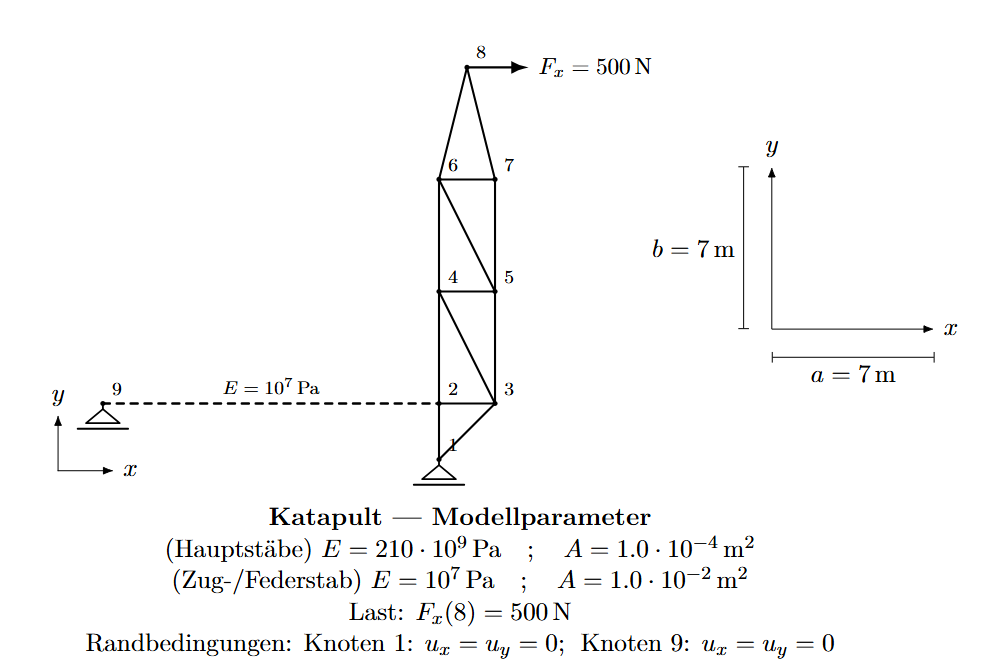

### Umsetzung im eigenem Preprozessor

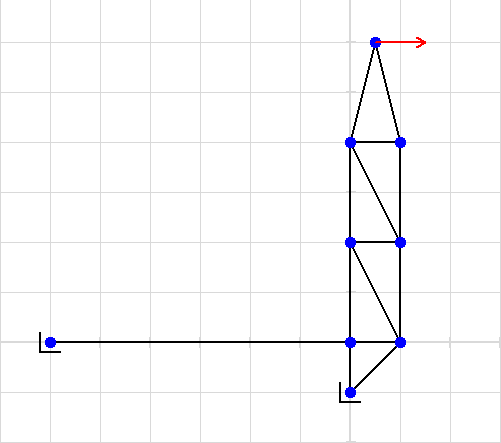

### Ergebnis im eigenem Postprozessor

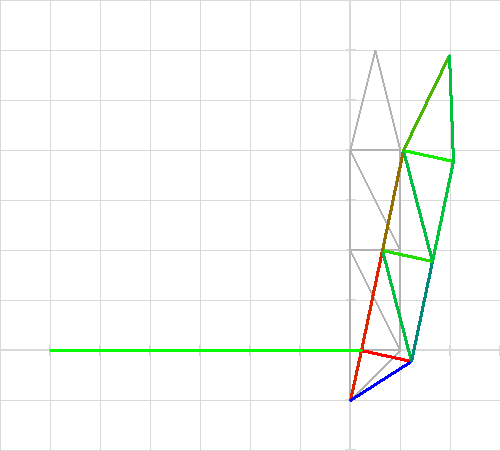
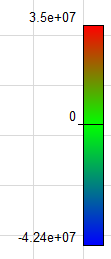

## Vergleich der Ergebnisse

### Verschiebungen $u_x, u_y$

| Knoten (Prog) | Knoten (Abaqus) | ux_prog [m] | uy_prog [m] | ux_aba [m] |  uy_aba [m] | absdiff ux | absdiff uy | rel ux | rel uy |
| ------------: | --------------: | ----------: | ----------: | ---------: | ----------: | ---------: | ---------: | -----: | -----: |
|             1 |               6 |           0 |           0 |         ~0 |           0 |         ~0 |          0 |      — |      — |
|             2 |               7 |        0.21 | 0.000142857 |       0.21 | 0.000142857 |          0 |          0 |      0 |      0 |
|             3 |               5 |    0.210167 |   -0.210571 |   0.210167 |   -0.210571 |          0 |          0 |      0 |      0 |
|             4 |               9 |    0.632431 | 0.000428571 |   0.632431 | 0.000428571 |          0 |          0 |      0 |      0 |
|             5 |               1 |    0.632455 |   -0.210761 |   0.632455 |   -0.210761 |          0 |          0 |      0 |      0 |
|             6 |               3 |     1.05548 | 0.000619048 |    1.05548 | 0.000619048 |          0 |          0 |      0 |      0 |
|             7 |               2 |     1.05549 |   -0.210856 |    1.05549 |   -0.210856 |          0 |          0 |      0 |      0 |
|             8 |               4 |     1.47886 |    -0.10512 |    1.47886 |    -0.10512 |          0 |          0 |      0 |      0 |
|             9 |               8 |           0 |           0 |         ~0 |           0 |         ~0 |          0 |      — |      — |


### Dehnung $\varepsilon$ und Spannung $\sigma$

| Element (Prog) | Element (Abaqus) | eps_prog [-] |  eps_aba [-] | absdiff eps | rel eps | sig_prog [Pa] | sig_aba [Pa] | absdiff sig | rel sig |
| -------------: | ---------------: | -----------: | -----------: | ----------: | ------: | ------------: | -----------: | ----------: | ------: |
|              1 |                7 |  1.42857E-04 |  1.42857E-04 |          ~0 |      ~0 |       3.0E+07 |      3.0E+07 |           0 |       0 |
|              2 |               11 |  1.66667E-04 |  1.66667E-04 |          ~0 |      ~0 |       3.5E+07 |      3.5E+07 |           0 |       0 |
|              3 |                6 | -2.02031E-04 | -2.02031E-04 |          ~0 |      ~0 |  -4.24264E+07 | -4.24264E+07 |           0 |       0 |
|              4 |               13 |  1.42857E-04 |  1.42857E-04 |          ~0 |      ~0 |       3.0E+07 |      3.0E+07 |           0 |       0 |
|              5 |                9 | -5.32397E-05 | -5.32397E-05 |          ~0 |      ~0 |  -1.11803E+07 | -1.11803E+07 |           0 |       0 |
|              6 |                5 | -9.52381E-05 | -9.52381E-05 |          ~0 |      ~0 |      -2.0E+07 |     -2.0E+07 |           0 |       0 |
|              7 |               10 |  2.38095E-05 |  2.38095E-05 |          ~0 |      ~0 |       5.0E+06 |      5.0E+06 |           0 |       0 |
|              8 |               14 |  9.52381E-05 |  9.52381E-05 |          ~0 |      ~0 |       2.0E+07 |      2.0E+07 |           0 |       0 |
|              9 |               12 | -5.32397E-05 | -5.32397E-05 |          ~0 |      ~0 |  -1.11803E+07 | -1.11803E+07 |           0 |       0 |
|             10 |                1 | -4.76190E-05 | -4.76190E-05 |          ~0 |      ~0 |      -1.0E+07 |     -1.0E+07 |           0 |       0 |
|             11 |                2 |  1.19048E-05 |  1.19048E-05 |          ~0 |      ~0 |       2.5E+06 |      2.5E+06 |           0 |       0 |
|             12 |                3 |  4.90846E-05 |  4.90846E-05 |          ~0 |      ~0 |   1.03078E+07 |  1.03078E+07 |           0 |       0 |
|             13 |                4 | -4.90846E-05 | -4.90846E-05 |          ~0 |      ~0 |  -1.03078E+07 | -1.03078E+07 |           0 |       0 |
|             14 |                8 |  3.50000E-02 |  3.50000E-02 |           0 |       0 |       3.5E+05 |      3.5E+05 |           0 |       0 |


### Reaktionskräfte $R_x, R_y$

| Knoten (Prog) | Knoten (Abaqus) | Rx_prog [N] |  Ry_prog [N] | Rx_aba [N] |   Ry_aba [N] | absdiff Rx | absdiff Ry | rel Rx |    rel Ry |
| ------------: | --------------: | ----------: | -----------: | ---------: | -----------: | ---------: | ---------: | -----: | --------: |
|             1 |               6 |        3000 | -4.65661E-10 |       3000 | -4.26098E-10 |          0 | 3.9563E-11 |      0 | 9.283E-02 |
|             9 |               8 |       -3500 |            0 |      -3500 |            0 |          0 |          0 |      0 |         — |


## Der Kran

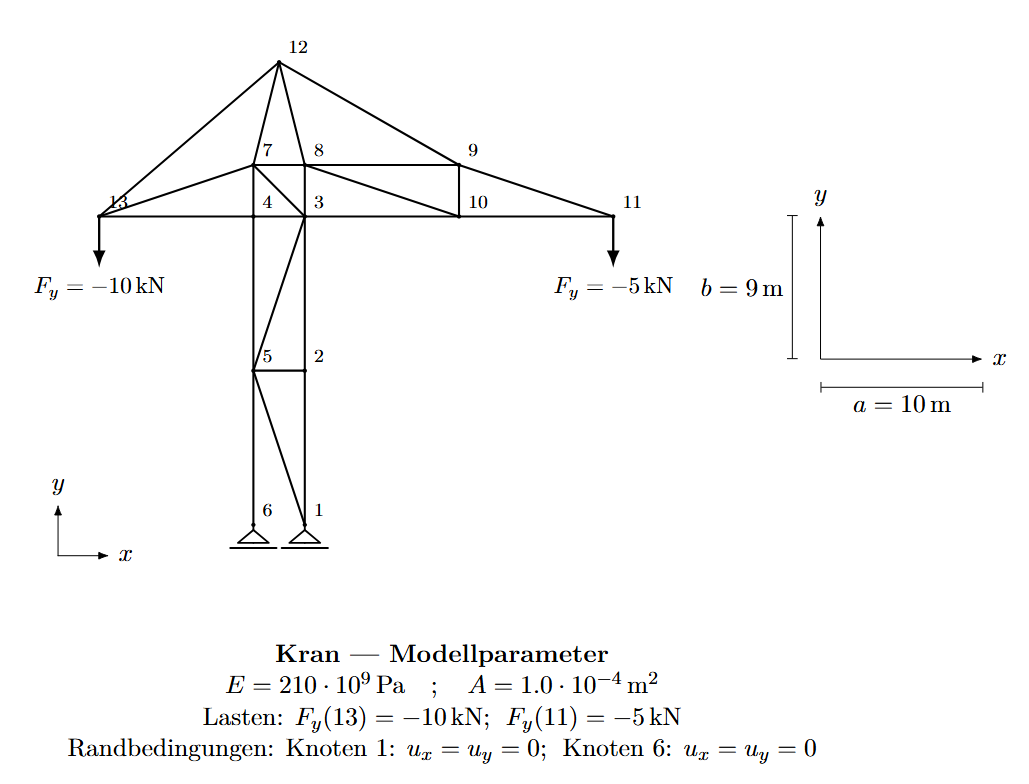

### Umsetzung im eigenem Preprozessor

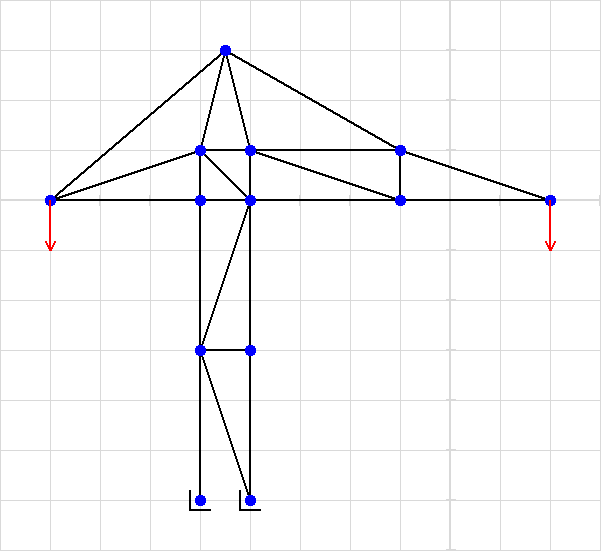

### Ergebnis im eigenem Postprozessor

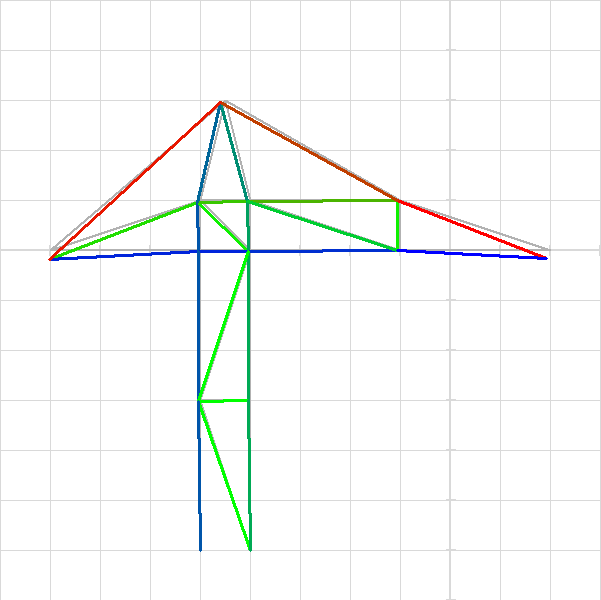
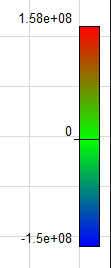

## Vergleich der Ergebnisse

### Verschiebungen

| Node (Abaqus) | Node (Prog) | U1_prog [m] | U1_abaqus [m] | relΔU1 |  U2_prog [m] | U2_abaqus [m] | relΔU2 |
| ------------: | ----------: | ----------: | ------------: | :----- | -----------: | ------------: | :----- |
|             1 |          11 |  -0.0054379 |    -0.0054379 | 0%     | -8.14577e-05 |  -8.14577e-05 | 0%     |
|             2 |          12 | -0.00818019 |   -0.00818019 | 0%     |   -0.0158376 |    -0.0158376 | 0%     |
|             3 |          10 | -0.00603733 |   -0.00603733 | 0%     | -0.000124929 |  -0.000124929 | 0%     |
|             4 |           5 | -0.00610254 |   -0.00610254 | 0%     |   -0.0016952 |    -0.0016952 | 0%     |
|             5 |           2 | -0.00428571 |   -0.00428571 | 0%     |  -0.00142857 |   -0.00142857 | 0%     |
|             6 |           4 | -0.00627119 |   -0.00627119 | 0%     |  -0.00333333 |   -0.00333333 | 0%     |
|             7 |          13 | -0.00992983 |   -0.00992983 | 0%     |  -0.00333128 |   -0.00333128 | 0%     |
|             8 |           9 | -0.00183607 |   -0.00183607 | 0%     |   -0.0176194 |    -0.0176194 | 0%     |
|             9 |           3 |  -0.0036733 |    -0.0036733 | 0%     |  -0.00285714 |   -0.00285714 | 0%     |
|            10 |           6 | -0.00428571 |   -0.00428571 | 0%     |  -0.00142857 |   -0.00142857 | 0%     |
|            11 |           7 | -0.00428571 |   -0.00428571 | 0%     | -0.000714286 |  -0.000714286 | 0%     |
|            12 |           8 |           0 |             0 | 0%     |            0 |             0 | 0%     |
|            13 |           1 |           0 |             0 | 0%     |            0 |             0 | 0%     |


### Elemente (lokal axial) Verzerrung & Spannung Prog vs Abaqus

| Element (Abaqus) | Element (Prog) | E11_prog [-] | E11_abaqus [-] | relΔE11 [%] | S11_prog [Pa] | S11_abaqus [Pa] | relΔS11 [%] |
| ---------------: | -------------: | -----------: | -------------: | :---------- | ------------: | --------------: | :---------- |
|                1 |             16 |  0.000752923 |    0.000752923 | 0%          |   1.58114e+08 |     1.58114e+08 | 0%          |
|                2 |             17 | -0.000714286 |   -0.000714286 | 0%          |      -1.5e+08 |        -1.5e+08 | 0%          |
|                3 |             13 |  4.34709e-05 |    4.34709e-05 | 0%          |   9.12888e+06 |     9.12888e+06 | 0%          |
|                4 |             12 |  0.000221545 |    0.000221545 | 0%          |   4.65245e+07 |     4.65245e+07 | 0%          |
|                5 |             11 | -0.000266634 |   -0.000266634 | 0%          |   -5.5993e+07 |     -5.5993e+07 | 0%          |
|                6 |              4 |  4.03593e-05 |    4.03593e-05 | 0%          |   8.47545e+06 |     8.47545e+06 | 0%          |
|                7 |              7 | -0.000429463 |   -0.000429463 | 0%          |  -9.01871e+07 |    -9.01871e+07 | 0%          |
|                8 |             23 |  0.000567515 |    0.000567515 | 0%          |   1.19178e+08 |     1.19178e+08 | 0%          |
|                9 |             14 | -0.000583873 |   -0.000583873 | 0%          |  -1.22613e+08 |    -1.22613e+08 | 0%          |
|               10 |             15 | -0.000137467 |   -0.000137467 | 0%          |  -2.88681e+07 |    -2.88681e+07 | 0%          |
|               11 |              5 |  0.000168659 |    0.000168659 | 0%          |   3.54183e+07 |     3.54183e+07 | 0%          |
|               12 |              6 | -0.000319648 |   -0.000319648 | 0%          |  -6.71261e+07 |    -6.71261e+07 | 0%          |
|               13 |             24 |  0.000684057 |    0.000684057 | 0%          |   1.43652e+08 |     1.43652e+08 | 0%          |
|               14 |              2 | -0.000612411 |   -0.000612411 | 0%          |  -1.28606e+08 |    -1.28606e+08 | 0%          |
|               15 |              3 |  -0.00047619 |    -0.00047619 | 0%          |        -1e+08 |          -1e+08 | 0%          |
|               16 |             19 |   4.2514e-18 |     4.2826e-18 | 0%          |   8.92794e-07 |     8.99346e-07 | 0%          |
|               17 |             10 | -0.000238095 |   -0.000238095 | 0%          |        -5e+07 |          -5e+07 | 0%          |
|               18 |             21 | -0.000238095 |   -0.000238095 | 0%          |        -5e+07 |          -5e+07 | 0%          |
|               19 |             20 |            0 |              0 | 0%          |  -1.79999e-06 |    -6.83047e-07 | 0%          |
|               20 |              9 |  -0.00047619 |    -0.00047619 | 0%          |        -1e+08 |          -1e+08 | 0%          |
|               21 |              1 |  9.80695e-05 |    9.80695e-05 | 0%          |   2.05946e+07 |     2.05946e+07 | 0%          |
|               22 |              8 | -0.000612411 |   -0.000612411 | 0%          |  -1.28606e+08 |    -1.28606e+08 | 0%          |
|               23 |             22 |  -0.00047619 |    -0.00047619 | 0%          |        -1e+08 |          -1e+08 | 0%          |
|               24 |             18 |            0 |              0 | 0%          |   1.82146e-07 |               0 | 0%          |


### Reaktionskräfte (global) Prog vs Abaqus

| Node (Abaqus) | Node (Prog) | RF1_prog [N] | RF1_abaqus [N] | relΔRF1 [%] | RF2_prog [N] | RF2_abaqus [N] | relΔRF2 [%] |
| ------------: | ----------: | -----------: | -------------: | :---------- | -----------: | -------------: | :---------- |
|            12 |           8 | -5.68434e-11 |   -2.15999e-11 | 0%          |         5000 |           5000 | 0%          |
|            13 |           1 |            0 |              0 | 0%          |        10000 |          10000 | 0%          |


## Nachwort

Dass die Ergebnisse nur vernachlässigbare Abweichungen haben, erweckt auch mein Erstaunen.

# Der Code

 In der Sprechestunde werde ich persönlich Hilfe anbieten um den Umgang mit dem Code zu erklären. 

## Code des Solvers: 

In [ ]:
import os
import json
import math
from typing import Dict, List, Tuple

import numpy as np

BASE_DIR = os.path.dirname(__file__)
TEMP_DIR = os.path.join(BASE_DIR, "temp")
MODEL_PATH = os.path.join(TEMP_DIR, "model.json")
RESULTS_PATH = os.path.join(TEMP_DIR, "results.json")


def ensure_temp_dir():
    os.makedirs(TEMP_DIR, exist_ok=True)


def read_model():
    with open(MODEL_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


def assemble_system(model: Dict):
    nodes = model["nodes"]
    elements = model["elements"]
    supports_list = model.get("supports", [])
    loads_list = model.get("loads", [])

    node_ids = [n["id"] for n in nodes]
    id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    n_dof = 2 * len(nodes)

    K = np.zeros((n_dof, n_dof), dtype=float)
    R = np.zeros((n_dof,), dtype=float)

    def dof_index(nid: int) -> Tuple[int, int]:
        i = id_to_idx[nid]
        return 2 * i, 2 * i + 1

    for e in elements:
        n1 = next(n for n in nodes if n["id"] == e["n1"])
        n2 = next(n for n in nodes if n["id"] == e["n2"])
        x1, y1 = n1["x"], n1["y"]
        x2, y2 = n2["x"], n2["y"]
        dx, dy = x2 - x1, y2 - y1
        L = math.hypot(dx, dy)
        if L < 1e-12:
            continue
        c, s = dx / L, dy / L
        EA_L = e.get("E", model.get("defaults", {}).get("E", 210e9)) * e.get("A", model.get("defaults", {}).get("A", 1e-4)) / L
        ke = EA_L * np.array(
            [
                [ c*c,  c*s, -c*c, -c*s],
                [ c*s,  s*s, -c*s, -s*s],
                [-c*c, -c*s,  c*c,  c*s],
                [-c*s, -s*s,  c*s,  s*s],
            ],
            dtype=float,
        )
        dofs = (*dof_index(n1["id"]), *dof_index(n2["id"]))
        for i in range(4):
            for j in range(4):
                K[dofs[i], dofs[j]] += ke[i, j]

    for ld in loads_list:
        ux_i, uy_i = dof_index(ld["node"])  
        R[ux_i] += ld.get("fx", 0.0)
        R[uy_i] += ld.get("fy", 0.0)

    fixed_dofs = []
    for spt in supports_list:
        nid = spt["node"]
        ux_flag = bool(spt.get("ux", False))
        uy_flag = bool(spt.get("uy", False))
        dof_x, dof_y = dof_index(nid)
        if ux_flag:
            fixed_dofs.append(dof_x)
        if uy_flag:
            fixed_dofs.append(dof_y)

    all_dofs = np.arange(n_dof)
    fixed_dofs = np.array(sorted(set(fixed_dofs)), dtype=int)
    free_dofs = np.array([d for d in all_dofs if d not in set(fixed_dofs)], dtype=int)

    return K, R, free_dofs, fixed_dofs, id_to_idx


def solve_truss(model: Dict):
    K, R, free, fixed, id_to_idx = assemble_system(model)
    n_dof = K.shape[0]
    U = np.zeros(n_dof, dtype=float)

    Kff = K[np.ix_(free, free)]
    Rf = R[free]
    Uf = np.linalg.solve(Kff, Rf)
    U[free] = Uf

    reac_full = K @ U - R
    reactions = []
    for d in fixed:
        node_index = d // 2
        nid = next(k for k, v in id_to_idx.items() if v == node_index)
        if d % 2 == 0:
            reactions.append({"node": nid, "rx": float(reac_full[d]), "ry": 0.0})
        else:
            reactions.append({"node": nid, "rx": 0.0, "ry": float(reac_full[d])})

    reac_by_node: Dict[int, Tuple[float, float]] = {}
    for r in reactions:
        nid = r["node"]
        rx, ry = reac_by_node.get(nid, (0.0, 0.0))
        rx += r.get("rx", 0.0)
        ry += r.get("ry", 0.0)
        reac_by_node[nid] = (rx, ry)
    reactions_combined = [{"node": nid, "rx": float(rx), "ry": float(ry)} for nid, (rx, ry) in reac_by_node.items()]

    sum_rx = float(sum(r["rx"] for r in reactions_combined))
    sum_ry = float(sum(r["ry"] for r in reactions_combined))
    sum_R = float(math.hypot(sum_rx, sum_ry))


    node_ids = sorted(id_to_idx.keys(), key=lambda k: id_to_idx[k])
    node_results = []
    for nid in node_ids:
        i = id_to_idx[nid]
        node_results.append({"id": nid, "ux": float(U[2 * i]), "uy": float(U[2 * i + 1])})

    elem_results = []
    nodes = model["nodes"]
    elements = model["elements"]
    for e in elements:
        n1 = next(n for n in nodes if n["id"] == e["n1"])
        n2 = next(n for n in nodes if n["id"] == e["n2"])
        i1 = id_to_idx[n1["id"]]
        i2 = id_to_idx[n2["id"]]
        x1, y1 = n1["x"], n1["y"]
        x2, y2 = n2["x"], n2["y"]
        dx, dy = x2 - x1, y2 - y1
        L = math.hypot(dx, dy)
        if L < 1e-12:
            N = 0.0
            strain = 0.0
            stress = 0.0
        else:
            c, s = dx / L, dy / L
            ue = np.array([U[2 * i1], U[2 * i1 + 1], U[2 * i2], U[2 * i2 + 1]])
            delta = np.array([-c, -s, c, s]) @ ue
            E = e.get("E", model.get("defaults", {}).get("E", 210e9))
            A = e.get("A", model.get("defaults", {}).get("A", 1e-4))
            N = (E * A / L) * delta
            strain = delta / L
            stress = E * strain
        elem_results.append({
            "id": e["id"],
            "force": float(N),
            "strain": float(strain),
            "stress": float(stress),
        })

    results = {
        "nodes": node_results,
        "elements": elem_results,
        "reactions": reactions_combined,
        "reactions_sum": {"rx": sum_rx, "ry": sum_ry, "R": sum_R},
        "metadata": {
            "dof": int(n_dof),
            "free_dofs": int(getattr(free, 'size', len(free))),
            "fixed_dofs": int(getattr(fixed, 'size', len(fixed)))
        },
    }
    return results


def write_results(results: Dict):
    ensure_temp_dir()
    with open(RESULTS_PATH, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    print(f"Ergebnisse gespeichert: {RESULTS_PATH}")


def run_solver():
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Modelldatei nicht gefunden: {MODEL_PATH}. Bitte zuerst den Preprocessor ausführen.")
    model = read_model()
    results = solve_truss(model)
    write_results(results)


if __name__ == "__main__":
    run_solver()



## Code eines Falls für die Berechung: 

In [ ]:
{
  "nodes": [
    {
      "id": 1,
      "x": 0.0,
      "y": 0.0
    },
    {
      "id": 2,
      "x": 2.0,
      "y": 0.0
    },
    {
      "id": 3,
      "x": 4.0,
      "y": 0.0
    },
    {
      "id": 4,
      "x": 3.0,
      "y": 2.0
    },
    {
      "id": 5,
      "x": 1.0,
      "y": 2.0
    },
    {
      "id": 6,
      "x": -1.0,
      "y": 2.0
    },
    {
      "id": 7,
      "x": -2.0,
      "y": 0.0
    },
    {
      "id": 8,
      "x": -3.0,
      "y": 2.0
    },
    {
      "id": 9,
      "x": -4.0,
      "y": 0.0
    }
  ],
  "elements": [
    {
      "id": 1,
      "n1": 9,
      "n2": 8,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 2,
      "n1": 8,
      "n2": 7,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 3,
      "n1": 7,
      "n2": 9,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 4,
      "n1": 8,
      "n2": 6,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 5,
      "n1": 6,
      "n2": 5,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 6,
      "n1": 5,
      "n2": 4,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 7,
      "n1": 4,
      "n2": 3,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 8,
      "n1": 4,
      "n2": 2,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 9,
      "n1": 2,
      "n2": 5,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 10,
      "n1": 5,
      "n2": 1,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 11,
      "n1": 1,
      "n2": 6,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 12,
      "n1": 6,
      "n2": 7,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 13,
      "n1": 7,
      "n2": 1,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 14,
      "n1": 1,
      "n2": 2,
      "E": 200000000000.0,
      "A": 0.0016
    },
    {
      "id": 15,
      "n1": 2,
      "n2": 3,
      "E": 200000000000.0,
      "A": 0.0016
    }
  ],
  "supports": [
    {
      "node": 9,
      "ux": true,
      "uy": true
    },
    {
      "node": 3,
      "ux": false,
      "uy": true
    }
  ],
  "loads": [
    {
      "node": 1,
      "fx": 0.0,
      "fy": -20000.0
    }
  ],
  "defaults": {
    "E": 200000000000.0,
    "A": 0.0016
  }
}

## Code eine Ergebnisses:

In [ ]:
{
  "nodes": [
    {
      "id": 1,
      "ux": 0.0,
      "uy": 0.0
    },
    {
      "id": 2,
      "ux": 0.21000000000128885,
      "uy": 0.000142857142857986
    },
    {
      "id": 3,
      "ux": 0.21016666666795655,
      "uy": -0.21057072768577975
    },
    {
      "id": 4,
      "ux": 0.6324314634654166,
      "uy": 0.000428571428573958
    },
    {
      "id": 5,
      "ux": 0.6324552729892263,
      "uy": -0.2107612038762567
    },
    {
      "id": 6,
      "ux": 1.0554819745485937,
      "uy": 0.0006190476190508922
    },
    {
      "id": 7,
      "ux": 1.0554938793104984,
      "uy": -0.21085644197149475
    },
    {
      "id": 8,
      "ux": 1.4788561251322772,
      "uy": -0.10512018527146003
    },
    {
      "id": 9,
      "ux": 0.0,
      "uy": 0.0
    }
  ],
  "elements": [
    {
      "id": 1,
      "force": 3000.000000017706,
      "strain": 0.000142857142857986,
      "stress": 30000000.00017706
    },
    {
      "id": 2,
      "force": 3500.0000000217633,
      "strain": 0.00016666666666770302,
      "stress": 35000000.00021763
    },
    {
      "id": 3,
      "force": -4242.6406871439,
      "strain": -0.00020203050891161428,
      "stress": -42426406.871439
    },
    {
      "id": 4,
      "force": 3000.000000017706,
      "strain": 0.000142857142857986,
      "stress": 30000000.00017706
    },
    {
      "id": 5,
      "force": -1118.0339887612038,
      "strain": -5.323971375053351e-05,
      "stress": -11180339.887612037
    },
    {
      "id": 6,
      "force": -2000.000000007815,
      "strain": -9.523809523846738e-05,
      "stress": -20000000.00007815
    },
    {
      "id": 7,
      "force": 500.00000000494094,
      "strain": 2.3809523809759092e-05,
      "stress": 5000000.000049409
    },
    {
      "id": 8,
      "force": 2000.0000000078094,
      "strain": 9.523809523846711e-05,
      "stress": 20000000.000078093
    },
    {
      "id": 9,
      "force": -1118.033988759379,
      "strain": -5.323971375044662e-05,
      "stress": -11180339.88759379
    },
    {
      "id": 10,
      "force": -999.9999999996817,
      "strain": -4.761904761903246e-05,
      "stress": -9999999.999996817
    },
    {
      "id": 11,
      "force": 249.99999999897327,
      "strain": 1.1904761904713013e-05,
      "stress": 2499999.9999897326
    },
    {
      "id": 12,
      "force": 1030.7764064038574,
      "strain": 4.908459078113606e-05,
      "stress": 10307764.064038573
    },
    {
      "id": 13,
      "force": -1030.776406404423,
      "strain": -4.908459078116299e-05,
      "stress": -10307764.064044228
    },
    {
      "id": 14,
      "force": 3500.000000021481,
      "strain": 0.03500000000021481,
      "stress": 350000.0000021481
    }
  ],
  "reactions": [
    {
      "node": 1,
      "rx": 3000.0000000172295,
      "ry": -4.656612873077393e-10
    },
    {
      "node": 9,
      "rx": -3500.000000021481,
      "ry": 0.0
    }
  ],
  "reactions_sum": {
    "rx": -500.00000000425143,
    "ry": -4.656612873077393e-10,
    "R": 500.00000000425143
  },
  "metadata": {
    "dof": 18,
    "free_dofs": 14,
    "fixed_dofs": 4,
    "singular": false
  }
}